In [333]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("schran/insurance-premium-prediction")

print("Path to dataset files:", path)
destination_path = "../data"

# Ensure destination folder exists
os.makedirs(destination_path, exist_ok=True)

# Move files from source to destination
for file_name in os.listdir(path):
    full_file_path = os.path.join(path, file_name)
    if os.path.isfile(full_file_path):  # Check if it's a file
        shutil.move(full_file_path, os.path.join(destination_path, file_name))
        print(f"Moved: {file_name}")


Path to dataset files: /Users/suvedharam/.cache/kagglehub/datasets/schran/insurance-premium-prediction/versions/2


### Converting CSV file to Pandas Dataframe

In [334]:
import pandas as pd
import os

# Assuming the dataset is in CSV format
csv_file_path = os.path.join(destination_path, 'Insurance Premium Prediction Dataset.csv')
if os.path.isfile(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print("Dataset imported successfully!")
    print(df.head())  # Display the first few rows of the DataFrame
else:
    print(f"File not found: {csv_file_path}")

Dataset imported successfully!
    Age  Gender  Annual Income Marital Status  Number of Dependents  \
0  56.0    Male        99990.0        Married                   1.0   
1  46.0    Male         2867.0         Single                   1.0   
2  32.0  Female        30154.0       Divorced                   3.0   
3  60.0  Female        48371.0       Divorced                   0.0   
4  25.0  Female        54174.0       Divorced                   0.0   

  Education Level     Occupation  Health Score  Location    Policy Type  \
0        Master's            NaN     31.074627     Urban  Comprehensive   
1      Bachelor's            NaN     50.271335     Urban  Comprehensive   
2      Bachelor's            NaN     14.714909  Suburban  Comprehensive   
3             PhD  Self-Employed     25.346926     Rural  Comprehensive   
4     High School  Self-Employed      6.659499     Urban  Comprehensive   

   Previous Claims  Vehicle Age  Credit Score  Insurance Duration  \
0              NaN    

#### Dataframe Shape : 19 feature, 1 Target, 278860 records

In [335]:
df.shape  # Display the shape of the DataFrame

(278860, 20)

Columns in Dataset

In [336]:
print("Columns and their datatypes:")
print(df.dtypes)

Columns and their datatypes:
Age                     float64
Gender                   object
Annual Income           float64
Marital Status           object
Number of Dependents    float64
Education Level          object
Occupation               object
Health Score            float64
Location                 object
Policy Type              object
Previous Claims         float64
Vehicle Age               int64
Credit Score            float64
Insurance Duration        int64
Premium Amount          float64
Policy Start Date        object
Customer Feedback        object
Smoking Status           object
Exercise Frequency       object
Property Type            object
dtype: object


Policy start date does not provide details, so dropping it

In [337]:
df = df.drop(columns=['Policy Start Date'])
print(df.dtypes)
print(df.shape)

Age                     float64
Gender                   object
Annual Income           float64
Marital Status           object
Number of Dependents    float64
Education Level          object
Occupation               object
Health Score            float64
Location                 object
Policy Type              object
Previous Claims         float64
Vehicle Age               int64
Credit Score            float64
Insurance Duration        int64
Premium Amount          float64
Customer Feedback        object
Smoking Status           object
Exercise Frequency       object
Property Type            object
dtype: object
(278860, 19)


Missing Value Analysis

In [338]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print("Missing values in each column:")
print(missing_percentage)

Missing values in each column:
Age                      1.680055
Gender                   0.000000
Annual Income            5.004303
Marital Status           1.799828
Number of Dependents    10.000000
Education Level          0.000000
Occupation              29.150111
Health Score             3.800115
Location                 0.000000
Policy Type              0.000000
Previous Claims         29.150111
Vehicle Age              0.000000
Credit Score            10.000000
Insurance Duration       0.000000
Premium Amount           0.660188
Customer Feedback        6.580004
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
dtype: float64


Drop records with null in Premium value for analysis since the percentage is less than 1%

In [339]:
df = df[df['Premium Amount'].notnull()]
df.shape

(277019, 19)

For marital status, Occupation and Customer converting the nulls as category 'Missing'

In [340]:
df['Occupation'].fillna('Missing', inplace=True)
df['Customer Feedback'].fillna('Missing', inplace=True)
df['Marital Status'].fillna('Missing', inplace=True)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print("Missing values in each column:")
print(missing_percentage)

Missing values in each column:
Age                      1.681473
Gender                   0.000000
Annual Income            5.000018
Marital Status           0.000000
Number of Dependents     9.995343
Education Level          0.000000
Occupation               0.000000
Health Score             3.799378
Location                 0.000000
Policy Type              0.000000
Previous Claims         29.149264
Vehicle Age              0.000000
Credit Score             9.999314
Insurance Duration       0.000000
Premium Amount           0.000000
Customer Feedback        0.000000
Smoking Status           0.000000
Exercise Frequency       0.000000
Property Type            0.000000
dtype: float64


/var/folders/70/bv9d2gzn4373dn9w5fts5_f40000gp/T/ipykernel_74208/4079824771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Occupation'].fillna('Missing', inplace=True)
/var/folders/70/bv9d2gzn4373dn9w5fts5_f40000gp/T/ipykernel_74208/4079824771.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

Checking distribution of Categorical columns and mean premium amount

In [341]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} (Percentage) ---")
    print(df[col].value_counts(normalize=True, dropna=False) * 100)
    means = df.groupby(col)['Premium Amount'].mean().sort_values(ascending=False)
    print(f"\n--- {col} (Means) ---")
    print(means)


--- Gender (Percentage) ---
Gender
Male      50.126165
Female    49.873835
Name: proportion, dtype: float64

--- Gender (Means) ---
Gender
Female    967.038752
Male      965.203213
Name: Premium Amount, dtype: float64

--- Marital Status (Percentage) ---
Marital Status
Single      32.810385
Married     32.726997
Divorced    32.660937
Missing      1.801681
Name: proportion, dtype: float64

--- Marital Status (Means) ---
Marital Status
Missing     983.100781
Divorced    968.708932
Married     965.107534
Single      963.616244
Name: Premium Amount, dtype: float64

--- Education Level (Percentage) ---
Education Level
PhD            25.090337
Bachelor's     25.082034
Master's       25.037272
High School    24.790357
Name: proportion, dtype: float64

--- Education Level (Means) ---
Education Level
PhD            971.123372
Bachelor's     967.960896
Master's       967.147020
High School    958.150901
Name: Premium Amount, dtype: float64

--- Occupation (Percentage) ---
Occupation
Missing    

Key Findings for Categorical Data: 
1. The categorical variables are balanced and representative of all possible categories
2. Mean Premium is slight higher for females
3. The missing category defined for nulls under marrital status seems to have a higher premium followed by married,divorced and Single.
4. phD has a higher mean premium and High school having the lowest
5. Unemployed has a higher premium and the Self-Employed and missing has a similar average
6. Urban and Rural premiums looks similar with Suburban being slightly lower
7. Comprehensive and Basic have a similar mean premium and Premium being slightly lower for Policy Type
8. The mean premium is highest among the Poor customer service and the lowest among the missing category.
9. Non-smokers have lower premiums
10. Mean premium amount of those who exercise Daily is the highest and very close to those who raraly exercise.
11. Condos have the lowest mean premium and apartment has the highest. 



Numeric Variables in the dataset and their distribution

In [342]:
numeric_columns = df.select_dtypes(include=['float','int']).columns
print(numeric_columns)
df.describe()


Index(['Age', 'Annual Income', 'Number of Dependents', 'Health Score',
       'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration',
       'Premium Amount'],
      dtype='object')


,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,272361.000000,263168.000000,249330.000000,266494.000000,196270.000000,277019.000000,249319.000000,277019.000000,277019.000000
mean,41.020139,42095.013159,1.998267,28.583739,0.998105,9.519318,574.389365,5.007898,966.118667
std,13.548304,35443.338341,1.412300,15.964010,1.000770,5.767438,158.794989,2.581473,909.404567
min,18.000000,0.000000,0.000000,0.035436,0.000000,0.000000,300.000000,1.000000,0.000000
25%,29.000000,13591.000000,1.000000,16.149422,0.000000,5.000000,437.000000,3.000000,286.000000
50%,41.000000,32207.000000,2.000000,26.448428,1.000000,10.000000,575.000000,5.000000,688.000000
75%,53.000000,62176.500000,3.000000,38.964028,2.000000,15.000000,712.000000,7.000000,1367.000000
max,64.000000,149997.000000,4.000000,93.876090,9.000000,19.000000,849.000000,9.000000,4999.000000


Null values present in Age(~2%), Annual Income(5%), Number of Dependents(10%), Previous claims(~29%)  and credit score (~10%), Health Score (~3.8%)

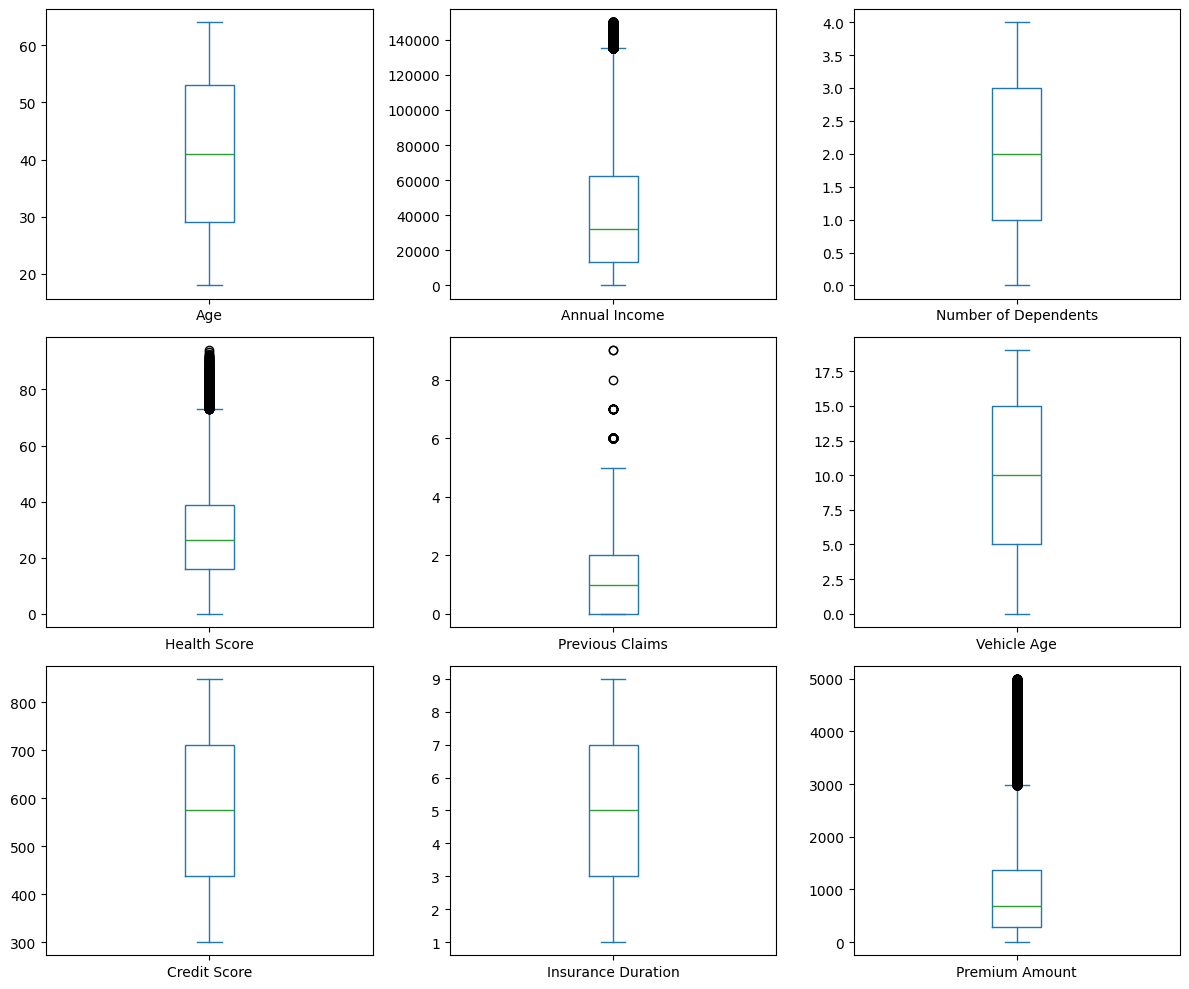

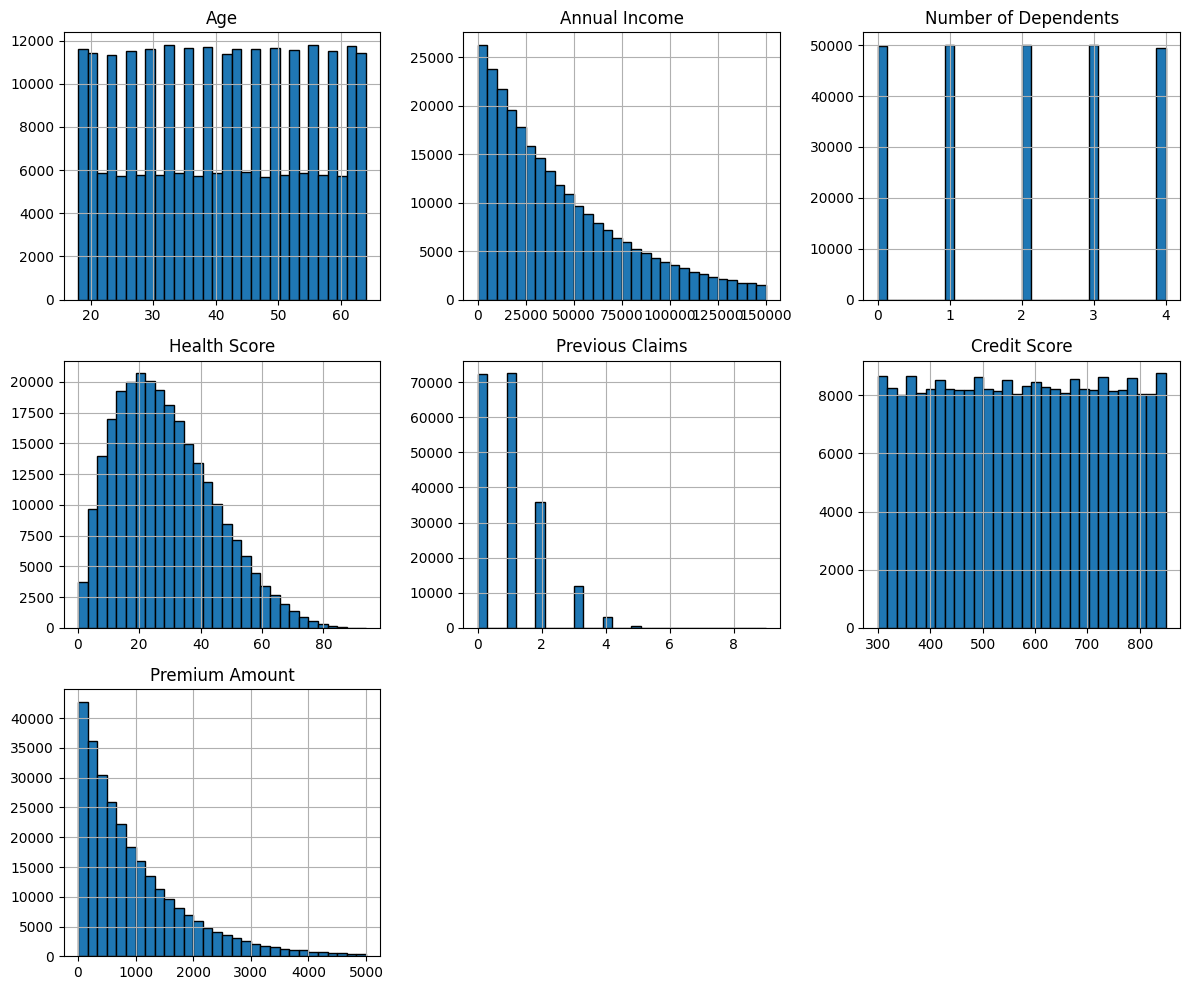

In [343]:
import matplotlib.pyplot as plt

df.select_dtypes(include=['float','int']).plot(
    kind='box',
    subplots=True,
    layout=(3, 3),  # 3 rows, 3 columns = 9 subplots possible
    figsize=(12, 10),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()

# Plot histograms for all numeric columns
df.select_dtypes(include='float64').hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

Age is uniformmly distributed and has less than 2% missing values, imputing based on prediction could be an over kill so going with imputation based on mean/median (same in this instance since data is not skewed)

In [345]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) 

Getting distinct values in Previous claim to decide, how to handle this column as it highly influences the premium amount. 
Key findings based on analysis:
1. 99% of the volumne has missing or 0-4 previous claims
2. Mean Premium amount for 8 and 9 claims is much lower based on the below data. This could be because of low volume.

Since most of the data lie between 0-4 claims, it is better to impute the missing values based on these 5 values alone or keep missing values as a separate category to see if that gives additional prediction power.

At this stage decided to keep missing (assigned as -1) as a separate category.

In [ ]:
print(df['Previous Claims'].unique())

print(f"\n--- Previous Claims (Percentage) ---")
print(df['Previous Claims'].value_counts(normalize=True, dropna=False) * 100)

means = df.copy()
means['Previous Claims'] = means['Previous Claims'].fillna(-1)  # Use -1 as placeholder for NaN
means = means.groupby('Previous Claims')['Premium Amount'].mean().sort_values(ascending=False)
print("\n--- Previous Claims (Means including NaN as -1) ---")
print(means)


#df['Previous Claims'] = df['Previous Claims'].fillna(-1)  # Fill NaN with -1


[nan  2.  1.  0.  3.  4.  5.  6.  7.  9.  8.]

--- Previous Claims (Percentage) ---
Previous Claims
NaN    29.149264
1.0    26.156329
0.0    26.101459
2.0    12.904530
3.0     4.322447
4.0     1.098842
5.0     0.224894
6.0     0.033572
7.0     0.007581
9.0     0.000722
8.0     0.000361
Name: proportion, dtype: float64

--- Previous Claims (Means including NaN as -1) ---
Previous Claims
 7.0    1245.000000
 4.0     988.312418
 1.0     970.800091
-1.0     966.567289
 0.0     964.113642
 3.0     962.251127
 5.0     961.417335
 2.0     959.113825
 6.0     934.376344
 9.0     685.500000
 8.0     256.000000
Name: Premium Amount, dtype: float64


For Nulls for Number of dependents(~10%), they seem to be distributed across different Marrital Status. We also had a Nulls in Marital status and the decision taken was to keep them as a separate category. 

The decision taken at this point was to impute the group mode of the number of dependents for a valid Marrital Status. For the missing category the global mode was imputed(0.18%). In addition flag called dependents_missing was added for extra information to the model.

In [347]:
print(df.groupby('Marital Status')['Number of Dependents'].value_counts(normalize=True, dropna=False) * 100)

df['dependents_missing'] = df['Number of Dependents'].isna()

df.loc[df['Marital Status'] != 'Missing', 'Number of Dependents'] = (
    df[df['Marital Status'] != 'Missing']
    .groupby('Marital Status')['Number of Dependents']
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0))
)

print('After Imputation for Non-Missing Marital Status:')
print(df.groupby('Marital Status')['Number of Dependents'].value_counts(normalize=True, dropna=False) * 100)




Marital Status  Number of Dependents
Divorced        2.0                     18.173679
                0.0                     18.085259
                3.0                     18.008997
                1.0                     17.951524
                4.0                     17.814472
                NaN                      9.966069
Married         3.0                     18.109420
                1.0                     18.088462
                2.0                     18.017869
                4.0                     17.914185
                0.0                     17.852416
                NaN                     10.017648
Missing         2.0                     18.873973
                4.0                     18.353035
                1.0                     17.812062
                0.0                     17.411340
                3.0                     17.371268
                NaN                     10.178321
Single          3.0                     18.074397
             

In [348]:
print(df['Number of Dependents'].value_counts(normalize=True, dropna=False) * 100)
global_mode = df['Number of Dependents'].mode()[0]
df['Number of Dependents'] = df['Number of Dependents'].fillna(global_mode)

print('After Global Mode Imputation:')
print(df['Number of Dependents'].value_counts(normalize=True, dropna=False) * 100)

Number of Dependents
3.0    24.608781
2.0    21.316588
1.0    18.031615
0.0    17.973857
4.0    17.885777
NaN     0.183381
Name: proportion, dtype: float64
After Global Mode Imputation:
Number of Dependents
3.0    24.792162
2.0    21.316588
1.0    18.031615
0.0    17.973857
4.0    17.885777
Name: proportion, dtype: float64


Annual Income and Credit Score are important features for Insurance Premium forecasting and there were records were both these values were nulls
In order to impute them - IterativeImputer was used.

What is IterativeImputer?
-It’s a multivariate imputation method that models each feature with missing values as a function of other features.
-It iteratively fills missing values by predicting them using regression models trained on other columns.
-It’s inspired by the MICE (Multiple Imputation by Chained Equations) algorithm.

In [349]:
df[(df['Annual Income'].isnull()) & (df['Credit Score'].isnull())].shape

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

# Add missing flags
df['annual_income_missing'] = df['Annual Income'].isna()
df['credit_score_missing'] = df['Credit Score'].isna()

# Select columns to impute
cols_to_impute = ['Annual Income', 'Credit Score']

imputer = IterativeImputer(random_state=0)

df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])
print("After Iterative Imputation:")
print(df[cols_to_impute].isnull().sum())

After Iterative Imputation:
Annual Income    0
Credit Score     0
dtype: int64


In [350]:
df['health_score_missing'] = df['Health Score'].isnull()

# Smoking vs missingness
smoking_means = df.groupby('Smoking Status')['health_score_missing'].mean()

# Exercise frequency vs missingness
exercis_means = df.groupby('Exercise Frequency')['health_score_missing'].mean()

#Location vs missingness
location_means = df.groupby('Location')['health_score_missing'].mean()

print("Smoking Status vs Health Score Missingness:")
print(smoking_means)
print("\nExercise Frequency vs Health Score Missingness:")
print(exercis_means)
print("\nLocation vs Health Score Missingness:")
print(location_means)




Smoking Status vs Health Score Missingness:
Smoking Status
No     0.037932
Yes    0.038055
Name: health_score_missing, dtype: float64

Exercise Frequency vs Health Score Missingness:
Exercise Frequency
Daily      0.038344
Monthly    0.037322
Rarely     0.038328
Weekly     0.037979
Name: health_score_missing, dtype: float64

Location vs Health Score Missingness:
Location
Rural       0.038376
Suburban    0.036491
Urban       0.039127
Name: health_score_missing, dtype: float64


In [351]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender', 'Marital Status', 'Education Level', 'Occupation',
            'Location', 'Policy Type', 'Customer Feedback',
            'Smoking Status', 'Exercise Frequency', 'Property Type']

# Make a copy to avoid modifying original
df_encoded = df.copy()

# Apply label encoding
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le  # Save encoders if needed later

features = ['Age', 'Exercise Frequency', 'Smoking Status', 
            'Previous Claims', 'Credit Score', 'Annual Income',
            'Education Level', 'Occupation', 'Insurance Duration','Health Score']
# Subset of the DataFrame
df_subset = df_encoded[features]

# Initialize and fit imputer
imputer = KNNImputer(n_neighbors=5, weights='uniform')
df_imputed = imputer.fit_transform(df_subset)

# Replace the health score column in original dataframe
df_encoded['Health Score'] = df_imputed[:, features.index('Health Score')]

# Convert back to original DataFrame 
df['Health Score'] = df_encoded['Health Score']


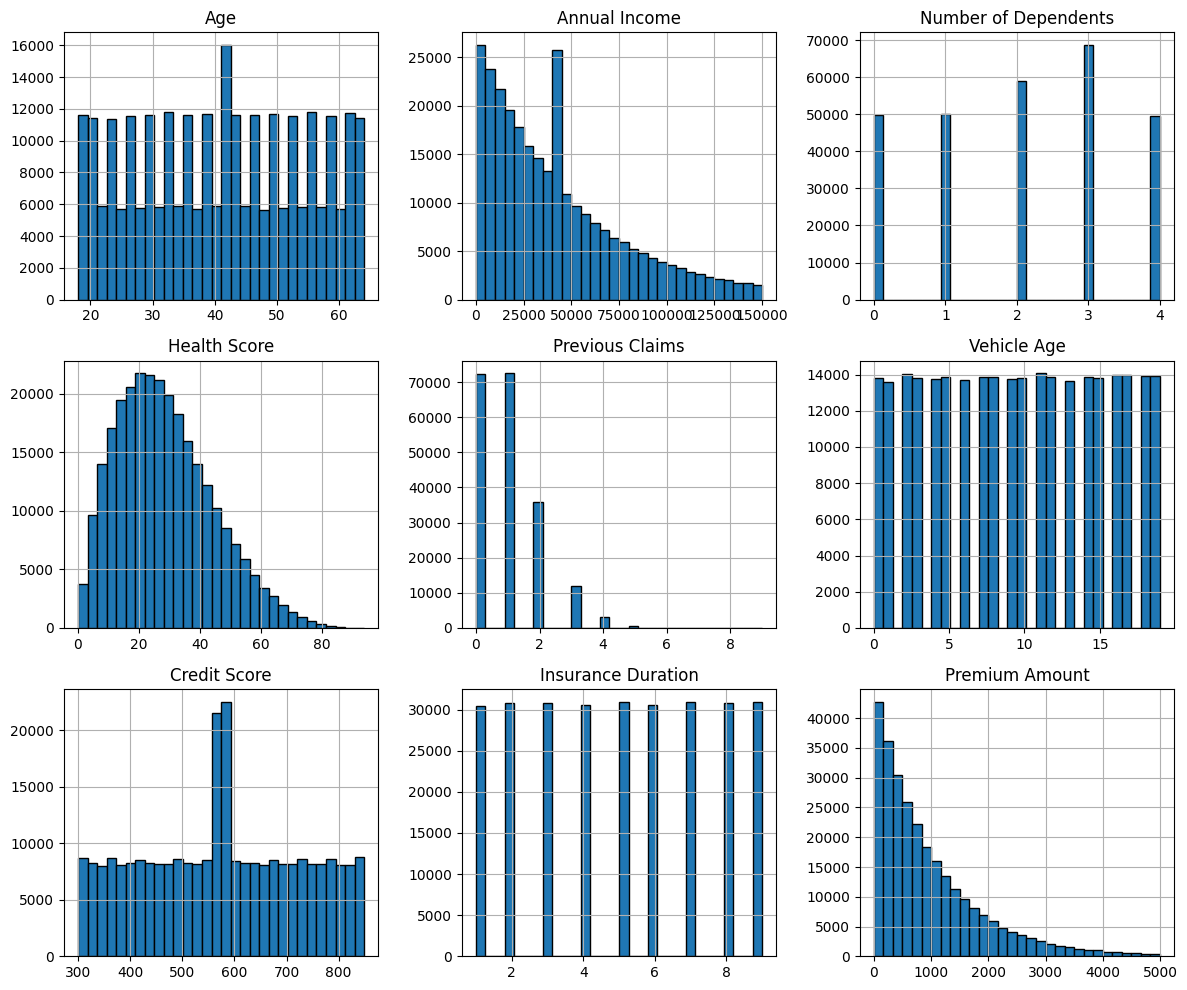

In [352]:

# Plot histograms for all numeric columns after imputation
df.select_dtypes(include=['float','int']).hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

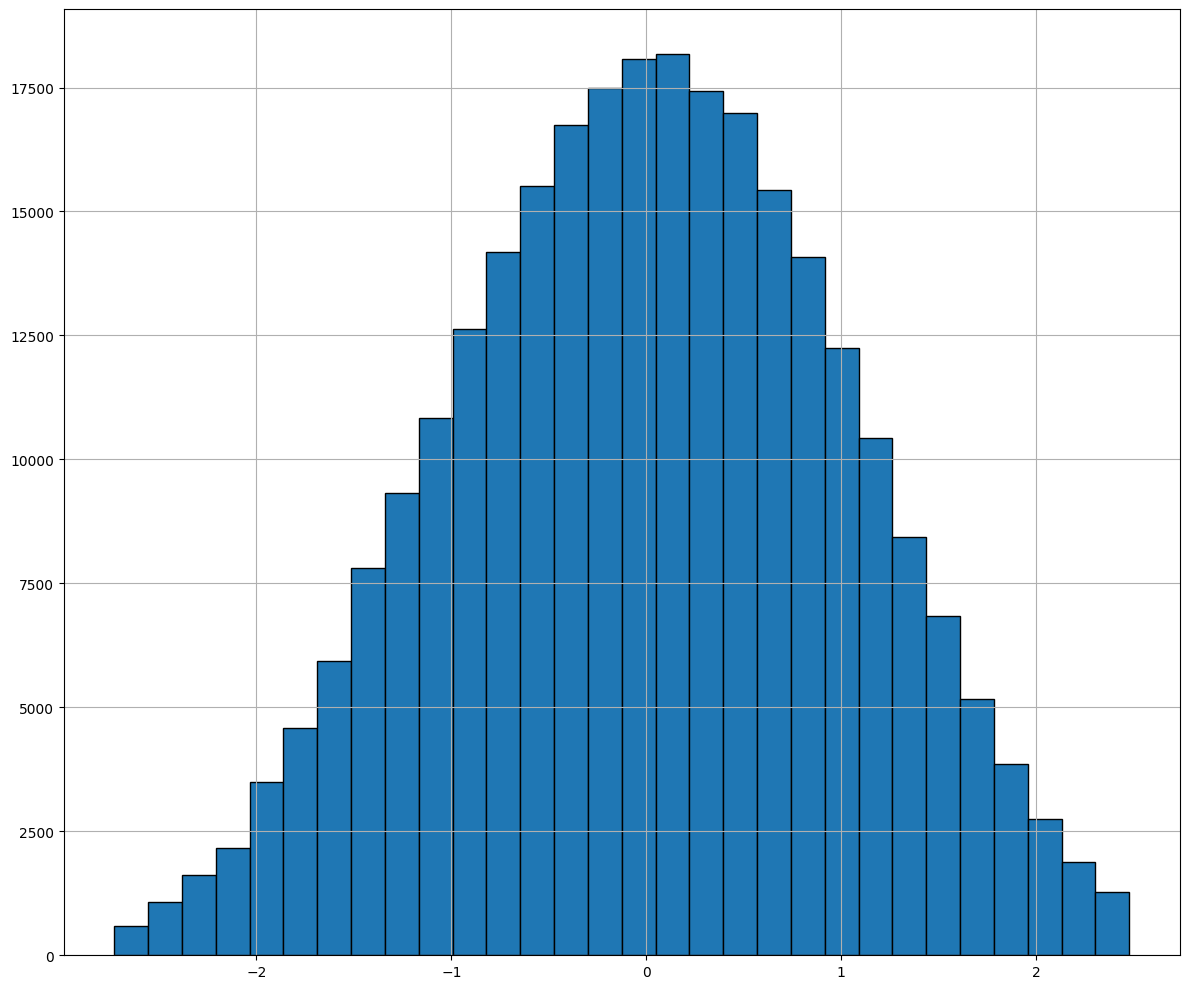

Lambda used for Premium Amount: 0.284865102763534


In [353]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df['premium_transformed'] = pt.fit_transform(df[['Premium Amount']])
df['premium_transformed'].hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()
print("Lambda used for Premium Amount:", pt.lambdas_[0])

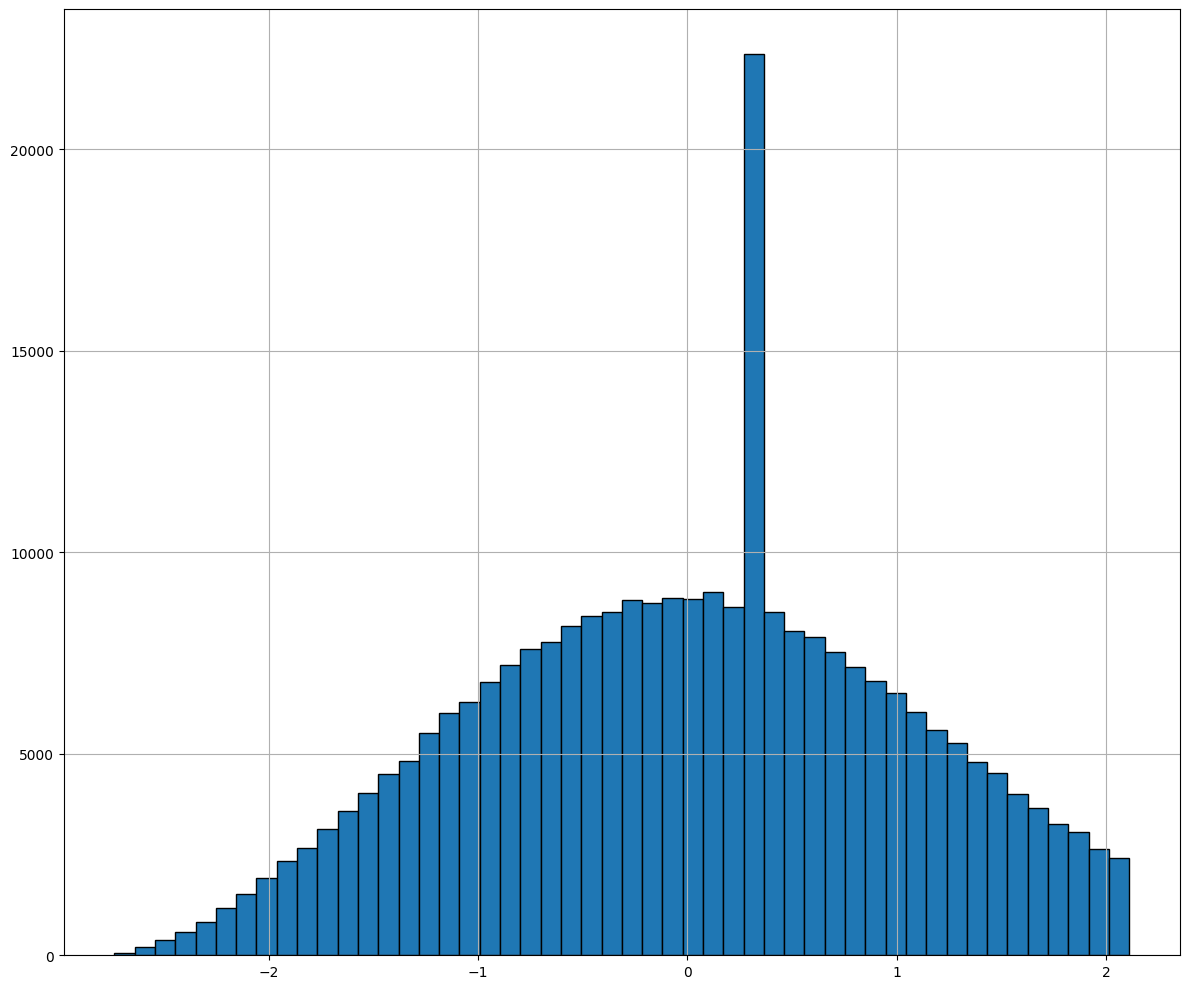

Lambda used for Annual Income: 0.3677819672682509


In [354]:
pt = PowerTransformer(method='yeo-johnson')
df['annual_income_transformed'] = pt.fit_transform(df[['Annual Income']])
df['annual_income_transformed'].hist(figsize=(12, 10), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()
print("Lambda used for Annual Income:", pt.lambdas_[0])

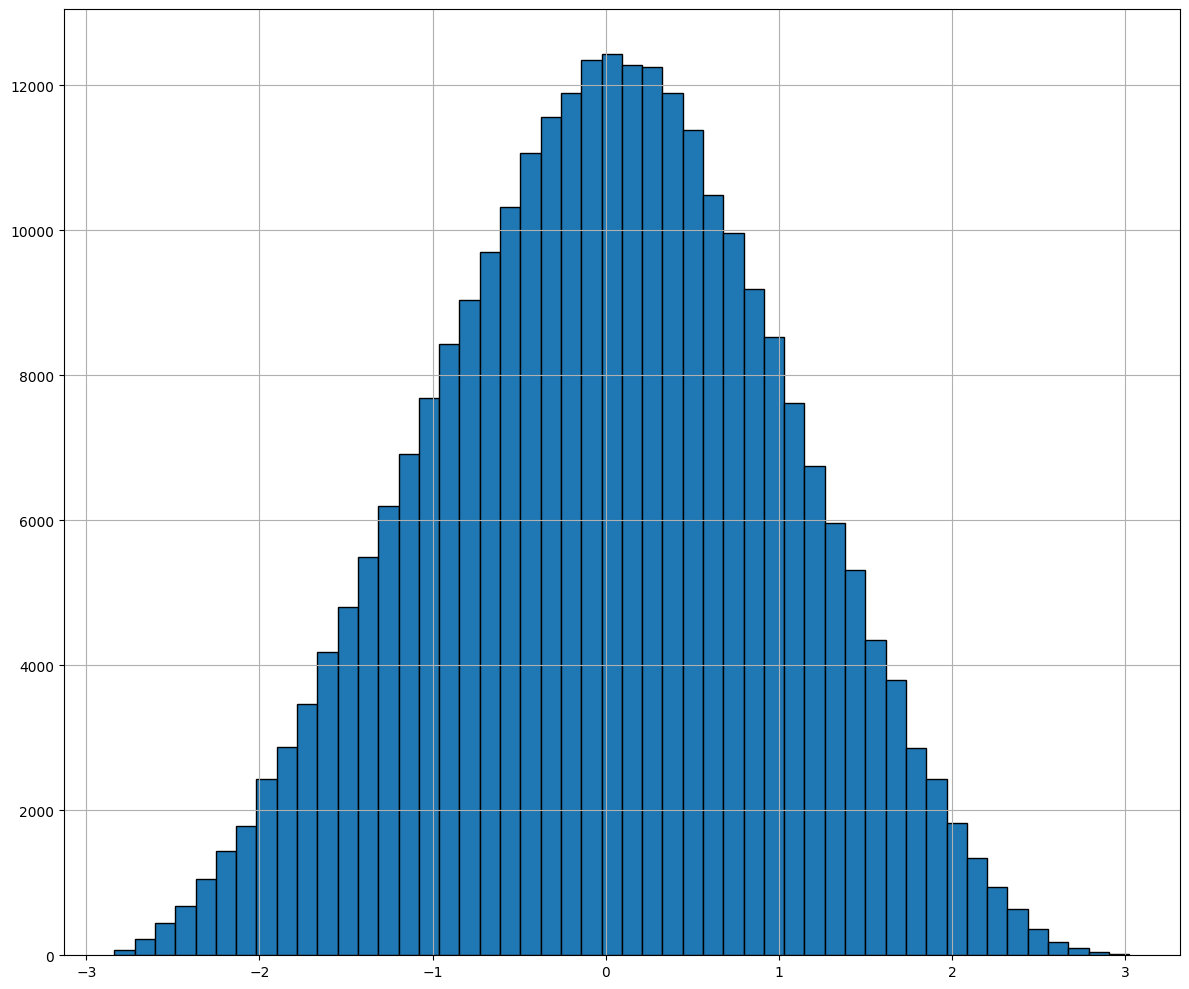

Lambda used for Health Score: 0.49710736767350444


In [355]:
pt = PowerTransformer(method='yeo-johnson')
df['health_score_transformed'] = pt.fit_transform(df[['Health Score']])
df['health_score_transformed'].hist(figsize=(12, 10), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()
print("Lambda used for Health Score:", pt.lambdas_[0])

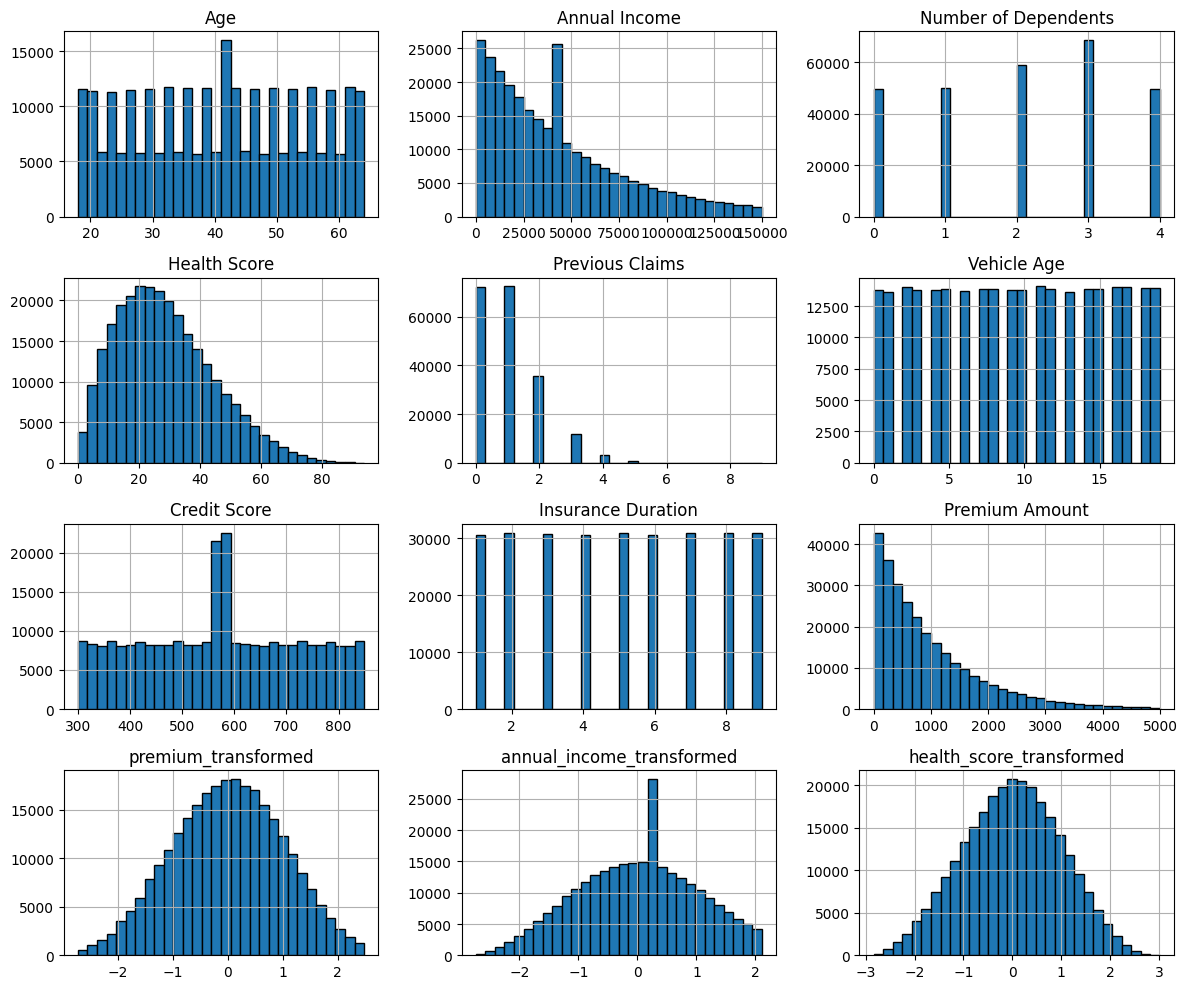

In [356]:
# Plot histograms for all numeric columns after imputation
df.select_dtypes(include=['float','int']).hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

In [357]:
# Create indicator columns for missingness
df['MaritalStatus_missing'] = df['Marital Status'].isnull().astype(int)
df['Occupation_missing'] = df['Occupation'].isnull().astype(int)
df['CustomerFeedback_missing'] = df['Customer Feedback'].isnull().astype(int)

# Compare mean Premium Amount for missing vs. non-missing
print("Marital Status:")
print(df.groupby('MaritalStatus_missing')['Premium Amount'].mean(), '\n')

print("Occupation:")
print(df.groupby('Occupation_missing')['Premium Amount'].mean(), '\n')

print("Customer Feedback:")
print(df.groupby('CustomerFeedback_missing')['Premium Amount'].mean())


Marital Status:
MaritalStatus_missing
0    966.118667
Name: Premium Amount, dtype: float64 

Occupation:
Occupation_missing
0    966.118667
Name: Premium Amount, dtype: float64 

Customer Feedback:
CustomerFeedback_missing
0    966.118667
Name: Premium Amount, dtype: float64


                                Age  Annual Income  Number of Dependents  \
Age                        1.000000       0.000108             -0.000634   
Annual Income              0.000108       1.000000              0.002854   
Number of Dependents      -0.000634       0.002854              1.000000   
Health Score               0.001719       0.001969              0.001858   
Previous Claims           -0.001311      -0.001492             -0.002675   
Vehicle Age                0.000662      -0.001224              0.001915   
Credit Score               0.000664      -0.003887             -0.002537   
Insurance Duration         0.000245      -0.000685             -0.001292   
Premium Amount             0.001846       0.000457              0.000029   
premium_transformed        0.003150       0.000374              0.000749   
annual_income_transformed  0.000794       0.945789              0.002498   
health_score_transformed   0.002479       0.001391              0.001747   
MaritalStatu

Text(0.5, 1.0, 'Correlation Heatmap: Premium Amount')

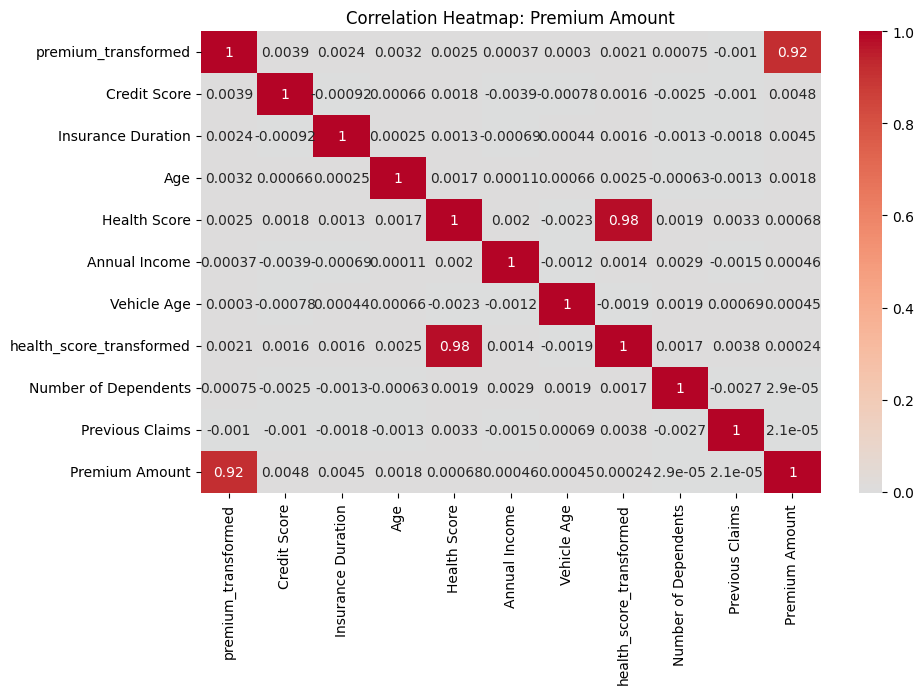

In [358]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float', 'int'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()
print(corr_matrix)

# View correlations with Premium Amount only
premium_corr = corr_matrix['Premium Amount'].sort_values(ascending=False)

print("Correlation with Premium Amount:")
print(premium_corr)

# Optional: heatmap of correlations (top N numeric features)
top_features = premium_corr[1:11].index  # top 10 excluding Premium Amount itself

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df[top_features.tolist() + ['Premium Amount']].corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: Premium Amount")




In [359]:
cat_cols = [
    'Gender',
    'Marital Status',
    'Education Level',
    'Occupation',
    'Location',
    'Policy Type',
    'Customer Feedback',
    'Smoking Status',
    'Exercise Frequency',
    'Property Type'
]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.drop(columns=['premium_transformed','health_score_transformed', 'annual_income_transformed'], inplace=True)
df_encoded.columns

Index(['Age', 'Annual Income', 'Number of Dependents', 'Health Score',
       'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration',
       'Premium Amount', 'dependents_missing', 'annual_income_missing',
       'credit_score_missing', 'health_score_missing', 'MaritalStatus_missing',
       'Occupation_missing', 'CustomerFeedback_missing', 'Gender_Male',
       'Marital Status_Married', 'Marital Status_Missing',
       'Marital Status_Single', 'Education Level_High School',
       'Education Level_Master's', 'Education Level_PhD', 'Occupation_Missing',
       'Occupation_Self-Employed', 'Occupation_Unemployed',
       'Location_Suburban', 'Location_Urban', 'Policy Type_Comprehensive',
       'Policy Type_Premium', 'Customer Feedback_Good',
       'Customer Feedback_Missing', 'Customer Feedback_Poor',
       'Smoking Status_Yes', 'Exercise Frequency_Monthly',
       'Exercise Frequency_Rarely', 'Exercise Frequency_Weekly',
       'Property Type_Condo', 'Property Type_Ho

In [360]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd


X = df_encoded.drop(columns=['Premium Amount']) 
y = df_encoded['Premium Amount']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [361]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [362]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)


In [ ]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


In [363]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}:\n  RMSE = {rmse:.2f}\n  R2   = {r2:.4f}\n")


In [364]:
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)
#evaluate_model("Neural Net", y_test, y_pred_mlp)
#evaluate_model("SVM", y_test, y_pred_svm)


Decision Tree:
  RMSE = 1331.34
  R2   = -1.1280

Random Forest:
  RMSE = 924.09
  R2   = -0.0252

XGBoost:
  RMSE = 913.71
  R2   = -0.0023



In [366]:
cat_cols = [
    'Gender',
    'Marital Status',
    'Education Level',
    'Occupation',
    'Location',
    'Policy Type',
    'Customer Feedback',
    'Smoking Status',
    'Exercise Frequency',
    'Property Type'
]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.drop(columns=['Premium Amount','Health Score','Annual Income'], inplace=True)
print(df_encoded.columns)

Index(['Age', 'Number of Dependents', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'dependents_missing',
       'annual_income_missing', 'credit_score_missing', 'health_score_missing',
       'premium_transformed', 'annual_income_transformed',
       'health_score_transformed', 'MaritalStatus_missing',
       'Occupation_missing', 'CustomerFeedback_missing', 'Gender_Male',
       'Marital Status_Married', 'Marital Status_Missing',
       'Marital Status_Single', 'Education Level_High School',
       'Education Level_Master's', 'Education Level_PhD', 'Occupation_Missing',
       'Occupation_Self-Employed', 'Occupation_Unemployed',
       'Location_Suburban', 'Location_Urban', 'Policy Type_Comprehensive',
       'Policy Type_Premium', 'Customer Feedback_Good',
       'Customer Feedback_Missing', 'Customer Feedback_Poor',
       'Smoking Status_Yes', 'Exercise Frequency_Monthly',
       'Exercise Frequency_Rarely', 'Exercise Frequency_Weekly',
       'Pro

In [367]:
X = df_encoded.drop(columns=['premium_transformed']) 
y = df_encoded['premium_transformed']
print(X.columns)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Index(['Age', 'Number of Dependents', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'dependents_missing',
       'annual_income_missing', 'credit_score_missing', 'health_score_missing',
       'annual_income_transformed', 'health_score_transformed',
       'MaritalStatus_missing', 'Occupation_missing',
       'CustomerFeedback_missing', 'Gender_Male', 'Marital Status_Married',
       'Marital Status_Missing', 'Marital Status_Single',
       'Education Level_High School', 'Education Level_Master's',
       'Education Level_PhD', 'Occupation_Missing', 'Occupation_Self-Employed',
       'Occupation_Unemployed', 'Location_Suburban', 'Location_Urban',
       'Policy Type_Comprehensive', 'Policy Type_Premium',
       'Customer Feedback_Good', 'Customer Feedback_Missing',
       'Customer Feedback_Poor', 'Smoking Status_Yes',
       'Exercise Frequency_Monthly', 'Exercise Frequency_Rarely',
       'Exercise Frequency_Weekly', 'Property Type_Condo',
       'Pro

In [368]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [369]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


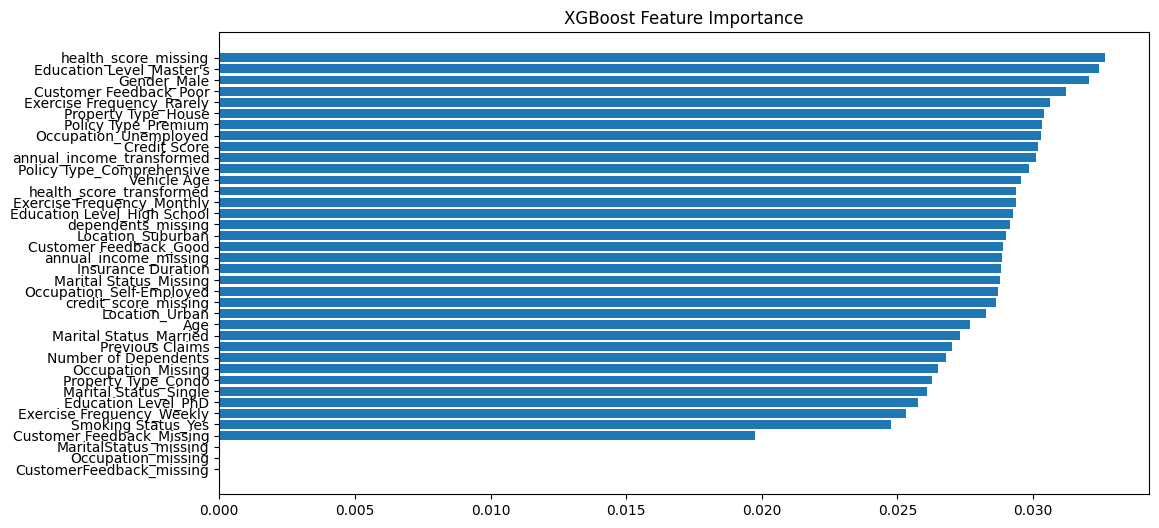

In [370]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

importances = xgb.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
import numpy as np
errors = np.abs(y_test - y_pred_xgb)
worst_cases = X_test.copy()
worst_cases['error'] = errors
worst_cases = worst_cases.sort_values('error', ascending=False).head(10)
print(worst_cases)


In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

In [ ]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [371]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}:\n  RMSE = {rmse:.2f}\n  R2   = {r2:.4f}\n")

In [372]:
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)
#evaluate_model("Neural Net", y_test, y_pred_mlp)
#evaluate_model("SVM", y_test, y_pred_svm)

Decision Tree:
  RMSE = 1.45
  R2   = -1.1014

Random Forest:
  RMSE = 1.01
  R2   = -0.0139

XGBoost:
  RMSE = 1.00
  R2   = -0.0022



In [ ]:
features = ['Age', 'Vehicle Age', 'Number of Dependents', 'Credit Score', 'Policy Type', 'Insurance Duration']

# Separate train and missing
known = df[df['Previous Claims'] != -1]
missing = df[df['Previous Claims'] == -1]

# One-hot encode Policy_Type
known_encoded = pd.get_dummies(known[features], drop_first=True)
missing_encoded = pd.get_dummies(missing[features], drop_first=True)

# Align columns (handle any missing dummy columns in either set)
missing_encoded = missing_encoded.reindex(columns=known_encoded.columns, fill_value=0)

X_train = known_encoded
y_train = known['Previous Claims']

X_missing = missing_encoded

# Train and predict
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

predicted_claims = rf.predict(X_missing)

df.loc[df['Previous Claims'] == -1, 'Previous Claims'] = predicted_claims


In [ ]:
cat_cols = [
    'Gender',
    'Marital Status',
    'Education Level',
    'Occupation',
    'Location',
    'Policy Type',
    'Customer Feedback',
    'Smoking Status',
    'Exercise Frequency',
    'Property Type'
]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.drop(columns=['Premium Amount','Health Score','Annual Income'], inplace=True)
print(df_encoded.columns)
print(df_encoded.shape)

In [ ]:
X = df_encoded.drop(columns=['premium_transformed']) 
y = df_encoded['premium_transformed']
print(X.columns)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

importances = xgb.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
evaluate_model("XGBoost", y_test, y_pred_xgb)

In [ ]:
bins = [300, 579, 669, 739, 799, 850]
labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
df['credit_score_bin'] = pd.cut(df['Credit Score'], bins=bins, labels=labels, include_lowest=True)


In [ ]:
cat_cols = [
    'Gender',
    'Marital Status',
    'Education Level',
    'Occupation',
    'Location',
    'Policy Type',
    'Customer Feedback',
    'Smoking Status',
    'Exercise Frequency',
    'Property Type',
    'credit_score_bin'
]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.drop(columns=['Premium Amount','Health Score','Annual Income','Credit Score','Previous Claims'], inplace=True)
print(df_encoded.columns)
print(df_encoded.shape)

In [ ]:
X = df_encoded.drop(columns=['premium_transformed']) 
y = df_encoded['premium_transformed']
print(X.columns)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

importances = xgb.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.show()

In [ ]:
evaluate_model("XGBoost", y_test, y_pred_xgb)

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)


In [ ]:
import shap

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_train)


In [ ]:
shap.summary_plot(shap_values, X_train)
